# 計算Si $E_f-E_v$

## 參數設定

* 參考FerroX預設參數
* 使用這個網站估算P++ Si的Na: https://www.pveducation.org/pvcdrom/materials/general-properties-of-silicon 

In [21]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.special import expit

# =========================
# Constants
# =========================

q = 1.602176634e-19
h = 6.62607015e-34
m0 = 9.1093837015e-31

kT_meV = 25.9
kT_J = kT_meV * 1e-3 * q

mp_eff = 0.81 * m0

Na = 5e19          # cm^-3
Nv = 1.83e19       # cm^-3
Ea_Ev_meV = 44     # meV
g = 0.25

# n0 * p0
n0p0_product = 8.5e19


# =========================
# p0 by dimensionless integral
# =========================


## Calculate p0 using Fermi-Dirac integral

* 因為very heavy dopping所以$E_f - E_v$ $\approx$ $kT$ 不能波茲曼近似，所以用原始公式︰
$$
p_0 =  \frac{4\pi(2{m_p}^*)^{3/2}}{h^3} (kT)^{3/2} \int_0^\infty \ \sqrt{u}[1-f(E_v-ukT)]\,du
\\, where \quad u=\frac{E_v-E}{kT}
$$





In [22]:

def p0_integral(Ef_Ev_meV):
    """
    Calculate p0 using Fermi-Dirac integral.

    Ev is set to 0.
    Ef_Ev_meV = Ef - Ev.

    Output: p0 in cm^-3
    """

    eta = Ef_Ev_meV / kT_meV

    A = 4 * np.pi * (2 * mp_eff)**1.5 / h**3

    prefactor_m3 = A * (kT_J)**1.5

    def integrand(u):
        # E = Ev - u*kT = -u*kT
        # (E - Ef)/kT = -u - eta
        one_minus_f = expit(-u - eta)
        return np.sqrt(u) * one_minus_f

    # 0 to 200 is enough because expit(-u-eta) decays exponentially
    integral, err = quad(
        integrand,
        0,
        200,
        epsabs=0,
        epsrel=1e-10,
        limit=300
    )

    p0_m3 = prefactor_m3 * integral
    p0_cm3 = p0_m3 / 1e6

    return p0_cm3

## 檢驗integral和 Boltzman在不同 $E_f-E_v$ 下的結果

* 結果顯示 $E_f-E_v > 2KT$ 左右時Boltzman近似誤差小，之後也幾乎貼合integral，符合理論。驗證integral是對的。

Ef - Ev =    2.590 meV, p0_integral = 1.2961e+19, p0_boltzmann = 1.6559e+19
Ef - Ev =    5.180 meV, p0_integral = 1.1953e+19, p0_boltzmann = 1.4983e+19
Ef - Ev =    7.770 meV, p0_integral = 1.1011e+19, p0_boltzmann = 1.3557e+19
Ef - Ev =   10.360 meV, p0_integral = 1.0131e+19, p0_boltzmann = 1.2267e+19
Ef - Ev =   12.950 meV, p0_integral = 9.3106e+18, p0_boltzmann = 1.1100e+19
Ef - Ev =   15.540 meV, p0_integral = 8.5477e+18, p0_boltzmann = 1.0043e+19
Ef - Ev =   18.130 meV, p0_integral = 7.8392e+18, p0_boltzmann = 9.0875e+18
Ef - Ev =   20.720 meV, p0_integral = 7.1826e+18, p0_boltzmann = 8.2227e+18
Ef - Ev =   23.310 meV, p0_integral = 6.5748e+18, p0_boltzmann = 7.4402e+18
Ef - Ev =   25.900 meV, p0_integral = 6.0133e+18, p0_boltzmann = 6.7322e+18
Ef - Ev =   28.490 meV, p0_integral = 5.4952e+18, p0_boltzmann = 6.0915e+18
Ef - Ev =   31.080 meV, p0_integral = 5.0178e+18, p0_boltzmann = 5.5119e+18
Ef - Ev =   33.670 meV, p0_integral = 4.5786e+18, p0_boltzmann = 4.9873e+18
Ef - Ev =   

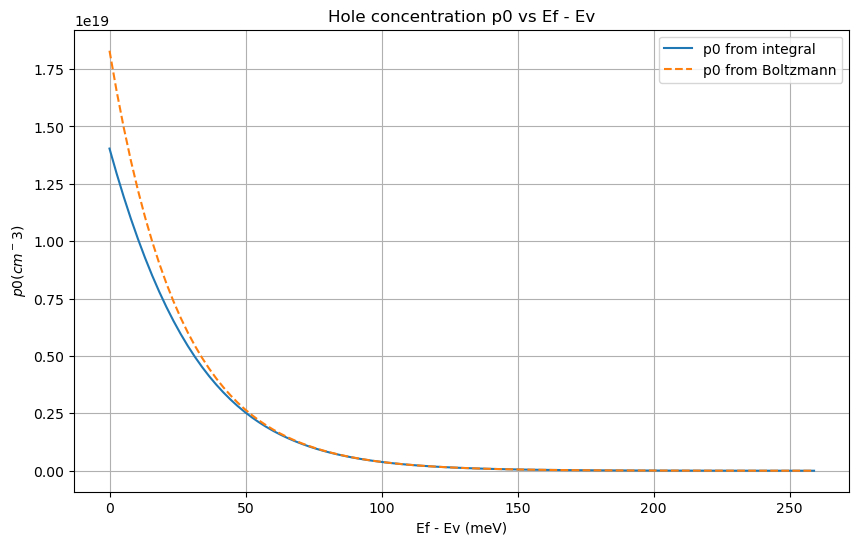

In [23]:
#check p0_integral against Boltzmann approximation
def p0_boltzmann(Ef_Ev_meV):    
    return Nv * np.exp(-Ef_Ev_meV / kT_meV)

# =========================
for i in range(1, 101):
    Ef_Ev_meV = 0.1*i * kT_meV
    p0_int = p0_integral(Ef_Ev_meV)
    p0_boltz = p0_boltzmann(Ef_Ev_meV)
    print(f"Ef - Ev = {Ef_Ev_meV:8.3f} meV, p0_integral = {p0_int:.4e}, p0_boltzmann = {p0_boltz:.4e}")

#plot p0 vs Ef - Ev
import matplotlib.pyplot as plt
Ef_Ev_range = np.linspace(0, 10 * kT_meV, 100)
p0_int_values = [p0_integral(Ef_Ev) for Ef_Ev in Ef_Ev_range]
p0_boltz_values = [p0_boltzmann(Ef_Ev) for Ef_Ev in Ef_Ev_range]    
plt.figure(figsize=(10, 6))
plt.plot(Ef_Ev_range, p0_int_values, label='p0 from integral')
plt.plot(Ef_Ev_range, p0_boltz_values, label='p0 from Boltzmann', linestyle='dashed')
plt.xlabel('Ef - Ev (meV)')
plt.ylabel('$p0 (cm^-3)$')
plt.title('Hole concentration p0 vs Ef - Ev')
plt.legend()
plt.grid()
plt.show()

## 用python root_scalar module迭代計算$E_f-E_v$

* 元件維持電中性︰$n_0+(N_a-p_a)=p_0+(N_d-n_d)=p_0\quad-(1)$
* hole concentration: $\quad p_0\quad integral \quad-(2)$
* holes in the acceptor energy state:
$$
p_a=\frac{N_a}{1+ge^{(\frac{E_f-E_a}{kT})}} \quad-(3)
$$
* 猜$E_f-E_a$計算(2)(3)直到滿足(1)
* 計算結果$E_f-E_v=27.122mev$
* Note:此時$E_f-E_a<0$

In [24]:




# =========================
# pa, n0, neutrality
# =========================

def calculate(Ef_Ea_meV):
    """
    Unknown variable:
        Ef_Ea_meV = Ef - Ea

    Ea - Ev = 44 meV
    Therefore:
        Ef - Ev = Ef - Ea + Ea - Ev
    """

    Ef_Ev_meV = Ef_Ea_meV + Ea_Ev_meV

    p0 = p0_integral(Ef_Ev_meV)

    pa = Na / (1 + g * np.exp(Ef_Ea_meV / kT_meV))

    n0 = n0p0_product / p0

    # neutrality:
    # n0 + (Na - pa) = p0
    error = n0 + (Na - pa) - p0

    return Ef_Ev_meV, p0, pa, n0, error


def neutrality_error(Ef_Ea_meV):
    return calculate(Ef_Ea_meV)[-1]


# =========================
# Scan
# =========================

print("Scan:")
for Ef_Ea in [-200, -150, -100, -75, -50, -25, 0, 25, 50]:
    Ef_Ev, p0, pa, n0, error = calculate(Ef_Ea)

    print(
        f"Ef-Ea = {Ef_Ea:8.3f} meV, "
        f"Ef-Ev = {Ef_Ev:8.3f} meV, "
        f"p0 = {p0:.4e}, "
        f"pa = {pa:.4e}, "
        f"Na-pa = {Na-pa:.4e}, "
        f"n0 = {n0:.4e}, "
        f"error = {error:.4e}"
    )


# =========================
# Find bracket automatically
# =========================

search_points = np.linspace(-300, 100, 161)

bracket = None
prev_x = search_points[0]
prev_f = neutrality_error(prev_x)

for x in search_points[1:]:
    fx = neutrality_error(x)

    if prev_f * fx < 0:
        bracket = [prev_x, x]
        break

    prev_x = x
    prev_f = fx


# =========================
# Solve
# =========================

if bracket is None:
    print("\nNo sign change found.")
    print("Try expanding the search range.")
else:
    print(f"\nBracket found: {bracket[0]:.3f} meV to {bracket[1]:.3f} meV")

    sol = root_scalar(
        neutrality_error,
        bracket=bracket,
        method="brentq",
        xtol=1e-8,
        rtol=1e-10
    )

    Ef_Ea_sol = sol.root
    Ef_Ev_sol, p0_sol, pa_sol, n0_sol, error_sol = calculate(Ef_Ea_sol)

    print("\nSolution:")
    print(f"converged = {sol.converged}")
    print(f"iterations = {sol.iterations}")
    print(f"Ef - Ea = {Ef_Ea_sol:.8f} meV")
    print(f"Ef - Ev = {Ef_Ev_sol:.8f} meV")
    print(f"p0 = {p0_sol:.6e} cm^-3")
    print(f"pa = {pa_sol:.6e} cm^-3")
    print(f"Na - pa = {Na - pa_sol:.6e} cm^-3")
    print(f"n0 = {n0_sol:.6e} cm^-3")
    print(f"left side  = n0 + (Na - pa) = {n0_sol + (Na - pa_sol):.6e}")
    print(f"right side = p0             = {p0_sol:.6e}")
    print(f"relative error = {error_sol / Na:.6e}")

Scan:
Ef-Ea = -200.000 meV, Ef-Ev = -156.000 meV, p0 = 2.1114e+20, pa = 4.9994e+19, Na-pa = 5.5365e+15, n0 = 4.0257e-01, error = -2.1114e+20
Ef-Ea = -150.000 meV, Ef-Ev = -106.000 meV, p0 = 1.2319e+20, pa = 4.9962e+19, Na-pa = 3.8138e+16, n0 = 6.8998e-01, error = -1.2315e+20
Ef-Ea = -100.000 meV, Ef-Ev =  -56.000 meV, p0 = 5.6256e+19, pa = 4.9738e+19, Na-pa = 2.6171e+17, n0 = 1.5109e+00, error = -5.5994e+19
Ef-Ea =  -75.000 meV, Ef-Ev =  -31.000 meV, p0 = 3.2773e+19, pa = 4.9319e+19, Na-pa = 6.8131e+17, n0 = 2.5936e+00, error = -3.2092e+19
Ef-Ea =  -50.000 meV, Ef-Ev =   -6.000 meV, p0 = 1.6798e+19, pa = 4.8250e+19, Na-pa = 1.7500e+18, n0 = 5.0600e+00, error = -1.5048e+19
Ef-Ea =  -25.000 meV, Ef-Ev =   19.000 meV, p0 = 7.6130e+18, pa = 4.5653e+19, Na-pa = 4.3472e+18, n0 = 1.1165e+01, error = -3.2659e+18
Ef-Ea =    0.000 meV, Ef-Ev =   44.000 meV, p0 = 3.1575e+18, pa = 4.0000e+19, Na-pa = 1.0000e+19, n0 = 2.6920e+01, error = 6.8425e+18
Ef-Ea =   25.000 meV, Ef-Ev =   69.000 meV, p0 = 1

# 只fit $\alpha, \beta, \gamma$

* 先假設簡單情況用簡單方法找出大致實驗參數
* 假設uniform polarization且$P_x=P_y=0, 即P=P_z$
* 假設實驗量測的是$Q_g=-Q_s \approx |P_z|$，假設沒漏電（已剔除漏電嚴重量測結果）
* 以下用$P代替Q_g$

## Math aspect

### Pr


* $P_r=P_{r0}\equiv |P|@E=0$
* 假設uniform polarization且 $P_x=P_y=0,P=P_z且steady \quad state$

* $free \quad energy \quad density=f=f_{Landau}+f_{electric}=\frac{1}{2}\alpha P^2+\frac{1}{4}\beta P^4+\frac{1}{6}\gamma P^6-EP$

* $TDGL \quad eq =>\frac{df}{dP}=\alpha P+\beta P^3+\gamma P^5-E=\frac{-1}{\Gamma}\frac{dP}{dt}=0\\$

* $E=\frac{V_{fe}}{t_{fe}}=\alpha P+\beta P^3+\gamma P^5\\$

* $Let \quad V_{fe}=t_{fe}P(\alpha +\beta P^2+\gamma P^4)=0\\$

* $Let \quad P^2=k,\quad t_{fe}P(\alpha +\beta k+\gamma k^2)=0\\$

* $公式解︰k=\frac{-\beta \pm \sqrt{\beta^2+4|\gamma||\alpha|}}{2 \gamma}\qquad \alpha 是負的for鐵電 \quad \gamma 是正的因為自由能才有極小值\\$

* $P=\pm \sqrt{\frac{-\beta \pm \sqrt{\beta^2+4|\gamma||\alpha|}}{2 \gamma}}$

* $P_{\pm,-}不存在$

* $P_{r}=P_{+,+}=+ \sqrt{\frac{-\beta + \sqrt{\beta^2+4|\gamma||\alpha|}}{2 |\gamma|}}$

* **調小|$\gamma$|或調大|$\alpha$|撐開PV loop**

## Express alpha, beta in terms of Pr, Ec 

* assume $E_c=E_{c0}\equiv |E|@\frac{dE}{dP}=0$ on the S curve
* assume $\gamma$ can be neglect
* $E=\frac{V_{fe}}{t_{fe}}=\alpha P+\beta P^3$
* $P_r=\pm\sqrt{\frac{|\alpha|}{\beta}}$
* $\frac{dE}{dP}=\alpha+3\beta P^2=0$
* $P_{c0}=\pm\sqrt{\frac{-\alpha}{3\beta}}=\pm\sqrt{\frac{|\alpha|}{3\beta}}$
* $E_{c}=\alpha P_{c0}+\beta P_{c0}^3=\pm\alpha\sqrt{\frac{|\alpha|}{3\beta}}\pm\beta{(\frac{|\alpha|}{3\beta})}^\frac{3}{2}=\pm{(\frac{|\alpha|^3}{3\beta})}^\frac{1}{2}\pm({\frac{|\alpha|}{3\beta^\frac{1}{3}}})^\frac{3}{2}=\mp\frac{|\alpha|^\frac{3}{2}}{{(3\beta)}^\frac{1}{2}}\pm\frac{|\alpha|^\frac{3}{2}}{{(27\beta)}^\frac{1}{2}}=\frac{\mp2|\alpha|^\frac{3}{2}}{(27\beta)^\frac{1}{2}}$
* **調小|$\alpha$|或調大|$\beta$|降|$E_{c}$|**
* We can express $\alpha$ and $\beta$ in terms of  $E_c$ and $P_r$

* **$|\alpha|=\frac{3\sqrt{3}E_c}{2P_r}$**

* **$\beta=\frac{3\sqrt{3}E_c}{2P_r^3}$**


## Express alpha, beta and gamma in terms of Pr, Ec and Pc0

### Conditions

* 假設uniform polarization且 $P_x=P_y=0,P=P_z且steady \quad state$
* $P_r=P_{r0}\equiv |P|@E=0$
* assume $E_c=E_{c0}\equiv |E|@\frac{dE}{dP}=0$ on the S curve
* $P_{c0}\equiv|P|@\frac{dE}{dP}=0$ on the S curve

### Reference 

* Aziz et al., "Physics-Based Circuit-Compatible SPICE Model for Ferroelectric Transistors," IEEE EDL, 2016.

### Expressions

* $r_p \equiv \frac{P_r}{P_{c0}}$
* $\alpha=-\frac{E_c}{P_{c0}}(\frac{r_p^2(3r_p^2-5)}{2(r_p^2-1)^2})$; $\beta=\frac{E_c}{P_{c0}^3}(\frac{(r_p^4-5)}{2(r_p^2-1)^2})$; $\gamma=-\frac{E_c}{P_{c0}^5}(\frac{(r_p^2-3)}{2(r_p^2-1)^2})$

* $\alpha=-\frac{E_c}{P_{r}}r_p(\frac{r_p^2(3r_p^2-5)}{2(r_p^2-1)^2})\equiv-\frac{E_c}{P_{r}}A(r_p)$

* $\beta=\frac{E_c}{P_{r}^3}r_p^3(\frac{(r_p^4-5)}{2(r_p^2-1)^2})\equiv\frac{E_c}{P_{r}^3}B(r_p)$

* $\gamma=-\frac{E_c}{P_{r}^5}r_p^5(\frac{(r_p^2-3)}{2(r_p^2-1)^2})\equiv-\frac{E_c}{P_{r}^5}C(r_p)$

* check1:代入 $\alpha P_r+\beta P_r^3+\gamma P_r^5=0$ (ok)

* check2:代入 $\alpha+3\beta P_{c0}^2+5\gamma P_{c0}^4=0$(ok)

* check3:代入 $E_c=2P_{c0}^3(\beta+2\gamma P_{c0}^2)$(ok)

* check4:let $\gamma=0$ 則 $r_p=\sqrt{3}$ 代入 $\alpha$ 和 $\beta$ 後得到和上個section一樣的結果(ok)  

### 二階相變(beta>0)

* $\alpha<0$ -> $3r_p^2-5>0$ -> $r_p>\sqrt{\frac{5}{3}}\approx 1.2910$
* $\beta>0$ -> $r_p^4-5>0$ -> $r_p>5^{\frac{1}{4}}\approx 1.4953$
* $\gamma>0$ -> $r_p^2-3<0$ -> $r_p<3^{\frac{1}{2}}\approx 1.7321$
* **所以$r_p$必須滿足$1.4953<r_p<1.7321$(或$0.5774<\frac{1}{r_p}<0.6687$)**

## Data generation

* 先測試Ec上下限
* 用typical value決定Pr上下限
* rp上下限用物理條件決定
* 依照尺度決定要log sampling 或linear sampling

### 2026/08/03 資料統計數據

In [11]:
from __future__ import annotations

from pathlib import Path
import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
EXCEL_PATH = Path("/home/gkaiwi58/FAM/FerroX/Exec/MFIS_dataset.xlsx")
EXPERIMENT_SHEET = "experiments"
PV_SHEET = "pv_curve"

In [13]:
experiments_raw = pd.read_excel(EXCEL_PATH, sheet_name=EXPERIMENT_SHEET)
print(f"experiments_raw.shape = {experiments_raw.shape}")
print("\nexperiments columns:")
print(list(experiments_raw.columns))

pv_raw = pd.read_excel(EXCEL_PATH, sheet_name=PV_SHEET)
print(f"\npv_raw.shape = {pv_raw.shape}")
print("\npv columns:")
print(list(pv_raw.columns))

experiments_raw.shape = (335, 28)

experiments columns:
['run_id', 'folder', 'inputs_path', 'pv_csv_path', 'pz_npz_path', 'n_pv_points', 'n_pz_stacks', 'T_FE', 'T_FE_nm', 'Start Time', 'End Time', 'Elapsed', 'Elapsed_sec', 'alpha', 'beta', 'gamma', 'BigGamma', 'g11', 'g44', 'FE_lo', 'FE_hi', 'Ec', 'Pr', 'Pc0', 'rp', 'landau_consistency_pass', 'valid_loop', 'has_multi']

pv_raw.shape = (12358, 5)

pv columns:
['folder', 'point_id', 'V_applied', 'branch', 'P_mean']


In [4]:
samples = experiments_raw
summary = pd.DataFrame(
    {
        "count": [
            len(samples),
            samples["folder"].nunique(),
            samples["T_FE_nm"].nunique(),
        ]
    },
    index=[
        "usable samples",
        "unique cases",
        "unique thickness values",
    ],
)

display(summary)

print("\nThickness counts:")

display(
    samples["T_FE_nm"]
    .value_counts()
    .sort_index()
    .rename_axis("T_FE_nm")
    .to_frame("count")
)

display(
    samples[
        ["alpha", "beta", "gamma", "T_FE_nm", "Ec", "Pr", "rp", "Pc0", "valid_loop", "has_multi"]
    ].describe().T
)

,count
usable samples,335
unique cases,335
unique thickness values,4



Thickness counts:


,count
T_FE_nm,
5.0,95
6.0,68
7.0,81
8.0,91


,count,mean,std,min,25%,50%,75%,max
alpha,335.0,-8.356779e+09,2.910369e+09,-3.000000e+10,-9.069314e+09,-8.000000e+09,-6.847942e+09,-6.532365e+05
beta,335.0,1.646393e+12,2.518326e+12,1.400000e+02,1.084729e+11,2.962434e+11,1.493000e+12,1.000000e+13
gamma,335.0,2.186981e+14,2.862624e+15,1.600000e+02,7.850129e+10,1.500000e+11,1.760339e+11,5.000000e+16
T_FE_nm,335.0,6.501493e+00,1.168126e+00,5.000000e+00,5.000000e+00,7.000000e+00,8.000000e+00,8.000000e+00
Ec,335.0,1.240387e+09,1.045692e+10,8.576796e+03,2.050092e+08,6.674853e+08,1.105518e+09,1.918147e+11
Pr,335.0,3.631784e-01,3.321111e+00,1.449135e-02,6.751863e-02,1.877806e-01,2.534018e-01,6.092165e+01
rp,335.0,1.699934e+00,4.941979e-02,1.495349e+00,1.697031e+00,1.724576e+00,1.732038e+00,1.732051e+00
Pc0,335.0,2.196175e-01,2.034473e+00,8.366593e-03,4.023024e-02,1.087187e-01,1.488484e-01,3.731675e+01


In [5]:
print(type(samples))
print(samples["valid_loop"])

<class 'pandas.DataFrame'>
0      0
1      1
2      1
3      1
4      1
      ..
330    0
331    0
332    1
333    1
334    0
Name: valid_loop, Length: 335, dtype: object


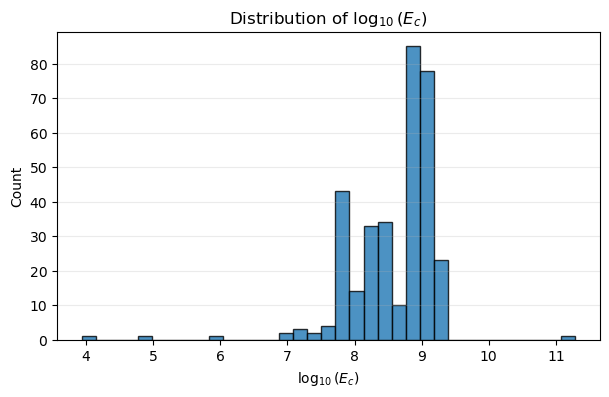

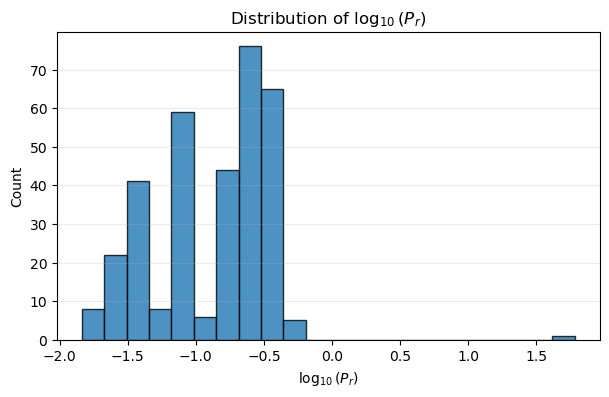

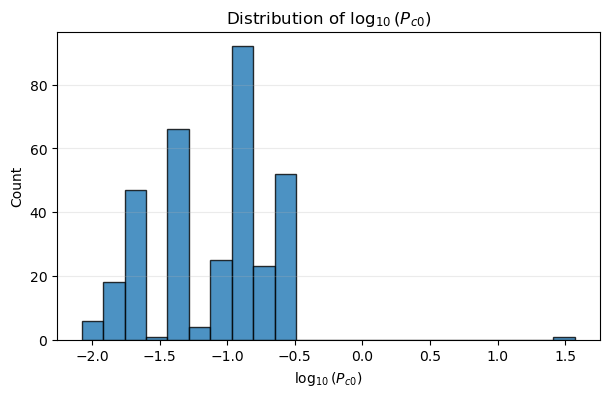

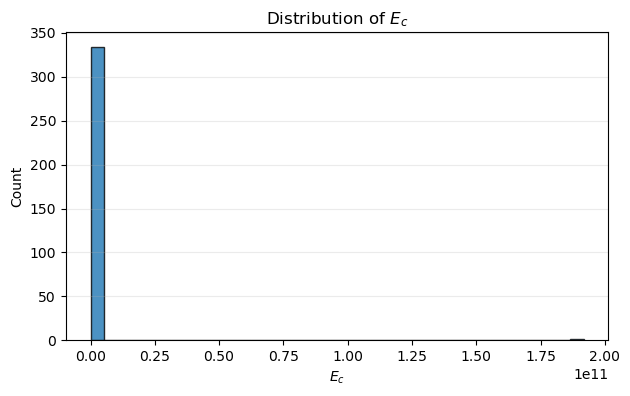

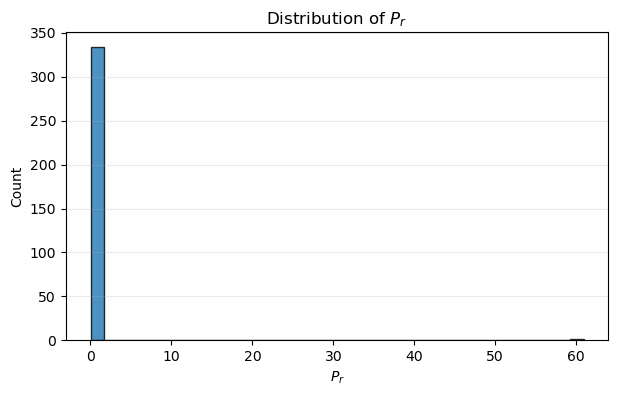

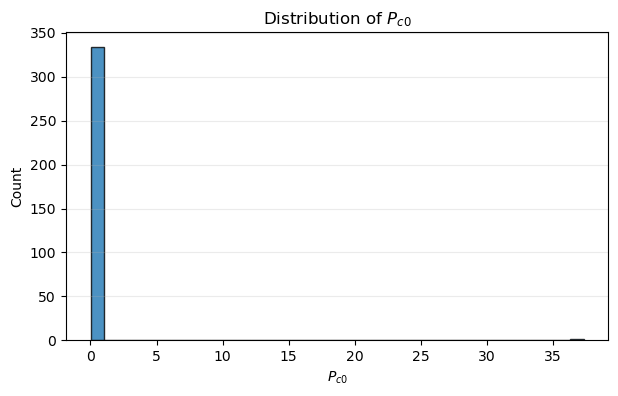

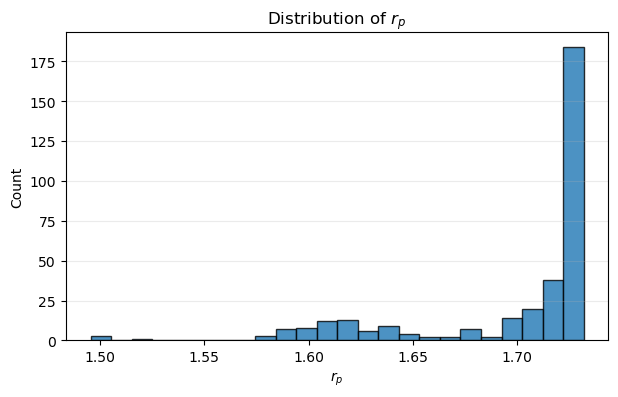

In [6]:
samples["log_Ec"] = np.log10(
    samples["Ec"].to_numpy(dtype=float)
)
samples["log_Pr"] = np.log10(
    samples["Pr"].to_numpy(dtype=float)
)
samples["log_Pc0"] = np.log10(
    samples["Pc0"].to_numpy(dtype=float)
)
for col, label in [
    ("log_Ec", r"$\log_{10}(E_c)$"),
    ("log_Pr", r"$\log_{10}(P_r)$"),
    ("log_Pc0", r"$\log_{10}(P_{c0})$"),
    ("Ec", r"$E_c$"),
    ("Pr", r"$P_r$"),
    ("Pc0", r"$P_{c0}$"),
    ("rp", r"$r_{p}$"),
]:
    plt.figure(figsize=(7, 4))
    plt.hist(
        samples[col],
        bins="auto",
        edgecolor="black",
        alpha=0.8,
    )
    plt.xlabel(label)
    plt.ylabel("Count")
    plt.title(f"Distribution of {label}")
    plt.grid(axis="y", alpha=0.25)
    plt.show()

In [7]:
experiments = experiments_raw.copy()

experiments["Ec"] = pd.to_numeric(
    experiments["Ec"],
    errors="coerce",
)

# 全部資料依 Ec 由小到大排序
experiments_sorted = experiments.sort_values(
    by="Ec",
    ascending=True,
)

# Ec 最小與最大的 10 個 case
ec_smallest_x = experiments.nsmallest(20, "Ec")
ec_largest_x = experiments.nlargest(20, "Ec")

print("Ec 最小的 20 個 case：")
display(ec_smallest_x)

print("Ec 最大的 20 個 case：")
display(ec_largest_x)

Ec 最小的 20 個 case：


,run_id,folder,inputs_path,pv_csv_path,pz_npz_path,n_pv_points,n_pz_stacks,T_FE,T_FE_nm,Start Time,...,Ec,Pr,Pc0,rp,landau_consistency_pass,valid_loop,has_multi,log_Ec,log_Pr,log_Pc0
327,MFIS_t_6_nomi_1_var_5_1,MFIS_t_6_nomi_1_var_5_1,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,6.000000e-09,6.0,2026-08-02 05:38:05.564,...,8.576796e+03,0.034112,0.019694,1.732044,True,0,0,3.933325,-1.467096,-1.705655
328,MFIS_t_6_nomi_1_var_5_2,MFIS_t_6_nomi_1_var_5_2,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,6.000000e-09,6.0,2026-08-02 05:38:14.213,...,8.576796e+04,0.034112,0.019694,1.732044,True,0,0,4.933325,-1.467096,-1.705655
329,MFIS_t_6_nomi_1_var_5_3,MFIS_t_6_nomi_1_var_5_3,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,6.000000e-09,6.0,2026-08-02 06:11:17.805,...,8.576796e+05,0.034112,0.019694,1.732044,True,0,0,5.933325,-1.467096,-1.705655
330,MFIS_t_6_nomi_1_var_5_4,MFIS_t_6_nomi_1_var_5_4,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_1_va...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,6.000000e-09,6.0,2026-08-02 06:11:53.346,...,8.576796e+06,0.034112,0.019694,1.732044,True,0,0,6.933325,-1.467096,-1.705655
230,MFIS_t_8_nomi_34,MFIS_t_8_nomi_34,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 01:24:30.000,...,1.171323e+07,0.014491,0.008367,1.732050,True,0,0,7.068677,-1.838891,-2.077451
232,MFIS_t_8_nomi_36,MFIS_t_8_nomi_36,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 17:19:03.769,...,1.342578e+07,0.015166,0.008756,1.732049,True,0,0,7.127940,-1.819137,-2.057697
233,MFIS_t_8_nomi_37,MFIS_t_8_nomi_37,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 20:25:33.696,...,1.431083e+07,0.015492,0.008944,1.732049,True,0,1,7.155665,-1.809895,-2.048455
231,MFIS_t_8_nomi_35,MFIS_t_8_nomi_35,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 11:21:09.990,...,1.521451e+07,0.015811,0.009129,1.732049,True,0,2,7.182258,-1.801031,-2.039591
229,MFIS_t_8_nomi_32,MFIS_t_8_nomi_32,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-08 13:34:37.439,...,1.999999e+07,0.017320,0.010000,1.732049,True,0,4,7.301030,-1.761440,-2.000001
334,MFIS_t_8_nomi_33,MFIS_t_8_nomi_33,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-09 21:36:54.835,...,1.999999e+07,0.017320,0.010000,1.732049,True,0,4,7.301030,-1.761440,-2.000001


Ec 最大的 20 個 case：


,run_id,folder,inputs_path,pv_csv_path,pz_npz_path,n_pv_points,n_pz_stacks,T_FE,T_FE_nm,Start Time,...,Ec,Pr,Pc0,rp,landau_consistency_pass,valid_loop,has_multi,log_Ec,log_Pr,log_Pc0
331,MFIS_t_5_nomi_3.5_gvar10_4_2_2,MFIS_t_5_nomi_3.5_gvar10_4_2_2,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-28 21:00:37.146,...,1.918147e+11,60.921646,37.316748,1.632555,True,0,37,11.282882,1.784772,1.571904
94,MFIS_t_7_nomi_13,MFIS_t_7_nomi_13,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,7.000000e-09,7.0,2026-06-30 10:48:50.135,...,2.440024e+09,0.357335,0.212706,1.679952,True,0,37,9.387394,-0.446924,-0.672221
288,MFIS_t_5_nomi_11_var_8,MFIS_t_5_nomi_11_var_8,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-24 23:45:47.492,...,2.139025e+09,0.475818,0.290683,1.636895,True,1,37,9.330216,-0.322559,-0.536580
93,MFIS_t_7_nomi_12,MFIS_t_7_nomi_12,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,7.000000e-09,7.0,2026-06-30 10:45:19.253,...,2.071027e+09,0.309791,0.182044,1.701734,True,0,37,9.316186,-0.508931,-0.739823
196,MFIS_t_8_nomi_24_var_5,MFIS_t_8_nomi_24_var_5,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-16 04:22:14.542,...,1.882962e+09,0.498555,0.304410,1.637777,True,1,37,9.274841,-0.302287,-0.516542
260,MFIS_t_5_nomi_8_var_10,MFIS_t_5_nomi_8_var_10,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-24 05:11:06.039,...,1.841666e+09,0.474492,0.289830,1.637142,True,0,37,9.265211,-0.323771,-0.537857
262,MFIS_t_6_nomi_4_var_2,MFIS_t_6_nomi_4_var_2,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_4_va...,/home/bowei/FAM/FerroX/Exec/MFIS_t_6_nomi_4_va...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,6.000000e-09,6.0,2026-07-23 05:45:48.064,...,1.759616e+09,0.419035,0.265450,1.578586,True,1,37,9.245418,-0.377750,-0.576018
91,MFIS_t_7_nomi_10,MFIS_t_7_nomi_10,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,7.000000e-09,7.0,2026-06-30 09:00:12.406,...,1.745939e+09,0.264538,0.154191,1.715645,True,0,37,9.242029,-0.577513,-0.811940
238,MFIS_t_8_nomi_8,MFIS_t_8_nomi_8,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-06-27 13:28:35.421,...,1.745939e+09,0.264538,0.154191,1.715645,True,0,37,9.242029,-0.577513,-0.811940
192,MFIS_t_8_nomi_24_var_10,MFIS_t_8_nomi_24_var_10,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-16 18:35:55.157,...,1.698013e+09,0.434900,0.271348,1.602737,True,1,37,9.229941,-0.361611,-0.566473


In [8]:
experiments = experiments_raw.copy()

experiments["Pr"] = pd.to_numeric(
    experiments["Pr"],
    errors="coerce",
)

# 全部資料依 Pr 由小到大排序
experiments_sorted = experiments.sort_values(
    by="Pr",
    ascending=True,
)

# Pr 最小與最大的 10 個 case
pr_smallest_x = experiments.nsmallest(20, "Pr")
pr_largest_x = experiments.nlargest(20, "Pr")

print("Pr 最小的 20 個 case：")
display(pr_smallest_x)

print("Pr 最大的 20 個 case：")
display(pr_largest_x)

Pr 最小的 20 個 case：


,run_id,folder,inputs_path,pv_csv_path,pz_npz_path,n_pv_points,n_pz_stacks,T_FE,T_FE_nm,Start Time,...,Ec,Pr,Pc0,rp,landau_consistency_pass,valid_loop,has_multi,log_Ec,log_Pr,log_Pc0
230,MFIS_t_8_nomi_34,MFIS_t_8_nomi_34,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 01:24:30.000,...,1.171323e+07,0.014491,0.008367,1.732050,True,0,0,7.068677,-1.838891,-2.077451
232,MFIS_t_8_nomi_36,MFIS_t_8_nomi_36,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 17:19:03.769,...,1.342578e+07,0.015166,0.008756,1.732049,True,0,0,7.127940,-1.819137,-2.057697
233,MFIS_t_8_nomi_37,MFIS_t_8_nomi_37,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 20:25:33.696,...,1.431083e+07,0.015492,0.008944,1.732049,True,0,1,7.155665,-1.809895,-2.048455
231,MFIS_t_8_nomi_35,MFIS_t_8_nomi_35,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-13 11:21:09.990,...,1.521451e+07,0.015811,0.009129,1.732049,True,0,2,7.182258,-1.801031,-2.039591
229,MFIS_t_8_nomi_32,MFIS_t_8_nomi_32,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-08 13:34:37.439,...,1.999999e+07,0.017320,0.010000,1.732049,True,0,4,7.301030,-1.761440,-2.000001
334,MFIS_t_8_nomi_33,MFIS_t_8_nomi_33,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-09 21:36:54.835,...,1.999999e+07,0.017320,0.010000,1.732049,True,0,4,7.301030,-1.761440,-2.000001
326,MFIS_t_5_nomi_3.5_gvar10_4_2_t4,MFIS_t_5_nomi_3.5_gvar10_4_2_t4,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-08-02 15:16:57.554,...,7.460412e+07,0.019260,0.012800,1.504665,True,1,0,7.872763,-1.715335,-1.892775
322,MFIS_t_5_nomi_2.4_5,MFIS_t_5_nomi_2.4_5,/home/bowei/FAM/FerroX/Exec/MFIS_t_5_nomi_2.4_...,/home/bowei/FAM/FerroX/Exec/MFIS_t_5_nomi_2.4_...,/home/bowei/FAM/FerroX/Exec/extracted_pz/MFIS_...,37,37,5.000000e-09,5.0,2026-07-28 12:37:47.844,...,5.709067e+07,0.020995,0.013251,1.584386,True,1,0,7.756565,-1.677883,-1.877744
9,MFIS_t_5_nomi_2.5_var_3,MFIS_t_5_nomi_2.5_var_3,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-20 22:00:02.665,...,4.870647e+07,0.024291,0.014025,1.732046,True,0,4,7.687587,-1.614549,-1.853109
14,MFIS_t_5_nomi_2.5_var_8,MFIS_t_5_nomi_2.5_var_8,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-21 03:42:21.465,...,4.712915e+07,0.024551,0.014175,1.732048,True,0,4,7.673290,-1.609928,-1.848488


Pr 最大的 20 個 case：


,run_id,folder,inputs_path,pv_csv_path,pz_npz_path,n_pv_points,n_pz_stacks,T_FE,T_FE_nm,Start Time,...,Ec,Pr,Pc0,rp,landau_consistency_pass,valid_loop,has_multi,log_Ec,log_Pr,log_Pc0
331,MFIS_t_5_nomi_3.5_gvar10_4_2_2,MFIS_t_5_nomi_3.5_gvar10_4_2_2,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_3...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-28 21:00:37.146,...,1.918147e+11,60.921646,37.316748,1.632555,True,0,37,11.282882,1.784772,1.571904
196,MFIS_t_8_nomi_24_var_5,MFIS_t_8_nomi_24_var_5,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-16 04:22:14.542,...,1.882962e+09,0.498555,0.304410,1.637777,True,1,37,9.274841,-0.302287,-0.516542
288,MFIS_t_5_nomi_11_var_8,MFIS_t_5_nomi_11_var_8,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-24 23:45:47.492,...,2.139025e+09,0.475818,0.290683,1.636895,True,1,37,9.330216,-0.322559,-0.536580
260,MFIS_t_5_nomi_8_var_10,MFIS_t_5_nomi_8_var_10,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-24 05:11:06.039,...,1.841666e+09,0.474492,0.289830,1.637142,True,0,37,9.265211,-0.323771,-0.537857
202,MFIS_t_8_nomi_26,MFIS_t_8_nomi_26,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-06-30 20:55:50.302,...,1.442669e+09,0.463067,0.269418,1.718767,True,1,37,9.159167,-0.334356,-0.569573
198,MFIS_t_8_nomi_24_var_7,MFIS_t_8_nomi_24_var_7,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-16 07:06:17.470,...,1.617835e+09,0.443714,0.273065,1.624938,True,1,37,9.208934,-0.352897,-0.563733
192,MFIS_t_8_nomi_24_var_10,MFIS_t_8_nomi_24_var_10,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-07-16 18:35:55.157,...,1.698013e+09,0.434900,0.271348,1.602737,True,1,37,9.229941,-0.361611,-0.566473
201,MFIS_t_8_nomi_25,MFIS_t_8_nomi_25,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi_2...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,8.000000e-09,8.0,2026-06-30 16:48:16.225,...,1.404602e+09,0.432648,0.258199,1.675638,True,1,37,9.147553,-0.363865,-0.588046
257,MFIS_t_5_nomi_8_var_7,MFIS_t_5_nomi_8_var_7,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_5_nomi_8...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,5.000000e-09,5.0,2026-07-23 23:14:13.914,...,1.580777e+09,0.430268,0.261995,1.642277,True,1,37,9.198871,-0.366261,-0.581707
106,MFIS_t_7_nomi_15_var_9,MFIS_t_7_nomi_15_var_9,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_1...,/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/MF...,37,37,7.000000e-09,7.0,2026-07-20 08:35:12.317,...,1.637087e+09,0.423548,0.260968,1.622985,True,1,37,9.214072,-0.373098,-0.583412


### add_valid_loop_to_excel.py 選取合理pv加入dataset

* 滿足以下條件者在MFIS_dataset.xlsx的experiments worksheet 的valid_loop設為1，反之0。

    1. $|P_r^+ - P_r^-| > $ open_threshold

    2. $P_r^+ >0$ and  $ P_r^- < 0$

    3. $|P_{start}-P_{end}| < $ close_threshold

* 其中open_threshold和close_threshold讓使用者經由觀察數據自行決定。  
* $P_r^-$為./file_name/figs/MFIS_PV_curve.csv中往下數第10個(標號11的row)plotfile的P_mean欄位*-1，  
$P_r^+$為./file_name/figs/MFIS_PV_curve.csv中往下數第28個(標號29的row)plotfile的P_mean欄位*-1。
* $P_{start}$ 為往下數第1個(標號2的raw)plotfile的P_mean欄位*-1
* $P_{end}$ 為往下數第37個(標號38的raw)plotfile的P_mean欄位*-1



### add_has_multi_to_excel.py 判斷是否形成multi-domain來限制alpha範圍

* 資料讀取方法，對於所有在extracted_pz內的檔案都處理，如果excel中的檔案extracted_pz沒有則該欄位註記沒資料
    ```
        npz_path = Path(
        "/home/gkaiwi58/FAM/FerroX/Exec/extracted_pz/"
        "MFIS_t_5_nomi_2.5_var_9/Pz_Phi_FE_all_voltage.npz"
        )

        data = np.load(
            npz_path,
            allow_pickle=True
        )

        # ==========================
        # Load data
        # ==========================

        Pz_stack = data["Pz_stack"]
    ```
* Pz_stack shape     : (37, 64, 11)
* 對於Pz_stack每個第一維度，選定第三維度index=5，沿著第二個維度方向紀錄$P_{min}$和$P_{max}$，若：  
    1. $|P_{max}-P_{min}| >$ var_threshold
    2. $P_{max}>0$ and $P_{min}<0$

    則在MFIS_dataset.xlsx的experiments worksheet 的has_multi設為1，結束遍歷第一維度。若37個電壓點都沒符合這條件，has_multi設為0。  
    var_threshold一樣是輸入參數靠觀察數據決定。


* 主列表項
    1. 子列表項
    * 另一個子列表項
        * 更深層的子列表項
* 另一個主列表項
    
    這是列表項中的段落，需要縮排。
    
    ```
    這是列表項中的代碼區塊，需要更多縮排。
    ```


### plot has_multi v.s. alpha

* $|\alpha|<6.25e9$ 

0      22
1       2
2      37
3      37
4       0
       ..
330     0
331    37
332     0
333    37
334     4
Name: has_multi, Length: 335, dtype: object
0      22.0
1       2.0
2      37.0
3      37.0
4       0.0
       ... 
330     0.0
331    37.0
332     0.0
333    37.0
334     4.0
Name: has_multi_num, Length: 335, dtype: float64


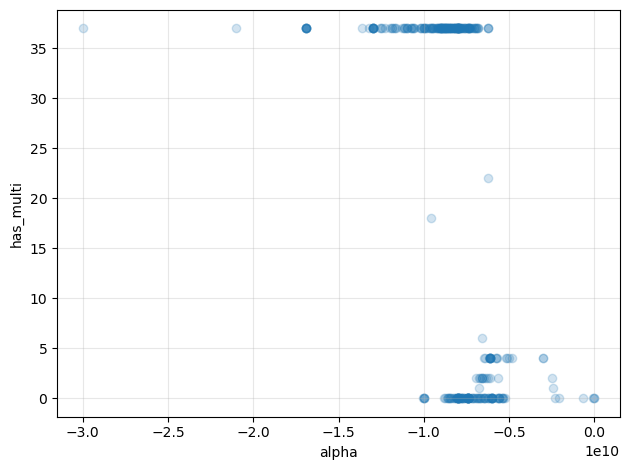

In [15]:
plot_samples = samples.copy()
print(plot_samples["has_multi"])
plot_samples["has_multi_num"] = pd.to_numeric(
    plot_samples["has_multi"],
    errors="coerce",
)
print(plot_samples["has_multi_num"])
plot_samples["alpha"] = pd.to_numeric(
    plot_samples["alpha"],
    errors="coerce",
)

plot_samples = plot_samples.dropna(
    subset=["alpha", "has_multi_num"],
)

plt.scatter(
    plot_samples["alpha"],
    plot_samples["has_multi_num"],
    alpha=0.2,
)

plt.xlabel("alpha")
plt.ylabel("has_multi")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### plot valid_loop v.s. Ec

* $5e7<E_c<2.5e9$

0      0
1      1
2      1
3      1
4      1
      ..
330    0
331    0
332    1
333    1
334    0
Name: valid_loop, Length: 335, dtype: object
0      0.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
330    0.0
331    0.0
332    1.0
333    1.0
334    0.0
Name: valid_loop_num, Length: 335, dtype: float64


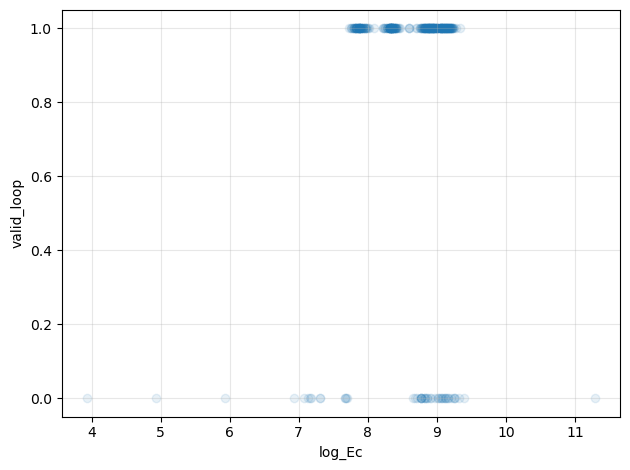

In [10]:
plot_samples = samples.copy()
print(plot_samples["valid_loop"])
plot_samples["valid_loop_num"] = pd.to_numeric(
    plot_samples["valid_loop"],
    errors="coerce",
)
print(plot_samples["valid_loop_num"])
plot_samples["log_Ec"] = pd.to_numeric(
    plot_samples["log_Ec"],
    errors="coerce",
)

plot_samples = plot_samples.dropna(
    subset=["log_Ec", "valid_loop_num"],
)

plt.scatter(
    plot_samples["log_Ec"],
    plot_samples["valid_loop_num"],
    alpha=0.1,
)

plt.xlabel("log_Ec")
plt.ylabel("valid_loop")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### plot P_r_all v.s. P_r

* $0.01449<P_r<1$

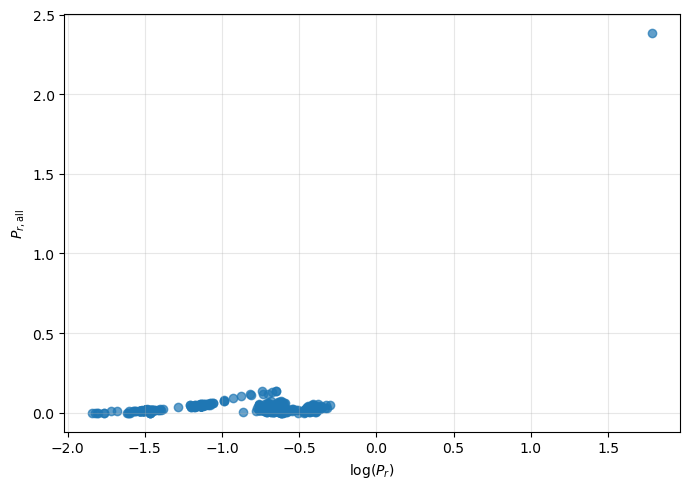

In [14]:
# 確保是數值
pv_raw["point_id"] = pd.to_numeric(pv_raw["point_id"], errors="coerce")
pv_raw["P_mean"] = pd.to_numeric(pv_raw["P_mean"], errors="coerce")
samples["log_Pr"] = pd.to_numeric(samples["log_Pr"], errors="coerce")

# 只留下 point_id = 9、27
pr_data = (
    pv_raw.loc[
        pv_raw["point_id"].isin([9, 27]),
        ["folder", "point_id", "P_mean"],
    ]
    .pivot(
        index="folder",
        columns="point_id",
        values="P_mean",
    )
    .rename(
        columns={
            9: "Pr_minus",
            27: "Pr_plus",
        }
    )
    .reset_index()
)

# FerroX 的 P_mean 需要乘以 -1
pr_data["Pr_minus"] *= -1
pr_data["Pr_plus"] *= -1

# Pr_all = (|Pr+| + |Pr-|) / 2
pr_data["Pr_all"] = (
    pr_data["Pr_plus"].abs()
    + pr_data["Pr_minus"].abs()
) / 2

# 與 experiments worksheet 合併
plot_samples = samples.merge(
    pr_data,
    on="folder",
    how="inner",
)

plot_samples = plot_samples.dropna(
    subset=["log_Pr", "Pr_all"],
)

# x = log(Pr)，y = 從 PV loop 取得的 Pr_all
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_samples["log_Pr"],
    plot_samples["Pr_all"],
    alpha=0.7,
)

plt.xlabel(r"$\log(P_r)$")
plt.ylabel(r"$P_{r,\mathrm{all}}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
cols = [
    "folder",
    "alpha",
    "beta",
    "gamma",
    "Ec",
    "Pr",
    "rp",
]

print(experiments_raw[cols].head().to_string(index=False))
print(experiments_raw[cols].dtypes)

          folder         alpha         beta        gamma           Ec       Pr       rp
   MFIS_t_5_nomi -6.250000e+09 1.000000e+11 1.500000e+11 5.925689e+08 0.239864 1.702557
 MFIS_t_5_nomi_1 -6.450000e+09 7.000000e+12 1.500000e+11 7.535937e+07 0.030355 1.732043
MFIS_t_5_nomi_10 -9.000000e+09 4.000000e+10 1.500000e+11 1.488418e+09 0.381515 1.617304
MFIS_t_5_nomi_11 -9.300000e+09 4.200000e+10 1.500000e+11 1.532939e+09 0.381651 1.620239
 MFIS_t_5_nomi_2 -6.000000e+09 7.000000e+12 1.500000e+11 6.761213e+07 0.029277 1.732044
folder        str
alpha     float64
beta      float64
gamma     float64
Ec        float64
Pr        float64
rp        float64
dtype: object


## Cases

* 假設uniform polarization且 $P_x=P_y=0,P=P_z且steady \quad state$
* $free \quad energy \quad density=f=f_{Landau}+f_{electric}=\frac{1}{2}\alpha P^2+\frac{1}{4}\beta P^4+\frac{1}{6}\gamma P^6-EP$

* $TDGL \quad eq =>\frac{df}{dP}=\alpha P+\beta P^3+\gamma P^5-E=\frac{-1}{\Gamma}\frac{dP}{dt}=0\\$

* $E=\frac{V_{fe}}{t_{fe}}=\alpha P+\beta P^3+\gamma P^5\\$
* $Let \quad \alpha < 0(鐵電) \quad \beta > 0(二階相變) \quad \gamma > 0(若<0 \quad free \quad energy \quad無最低點)$

* $\alpha$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\alpha P=>無非0根=>沒撐開PV$
* $\beta$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\beta P^3=>無非0根=>沒撐開PV$
* $\gamma$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\gamma P^5=>無非0根=>沒撐開PV$
* $\alpha$ term and $\beta$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\alpha P+\beta P^3=>非0根=\pm\sqrt{\frac{-\alpha}{\beta}}=\pm\sqrt{\frac{|\alpha|}{\beta}}$
* $\alpha$ term and $\gamma$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\alpha P+\gamma P^5=>非0根=\pm(\frac{-\alpha}{\gamma})^\frac{1}{4}=\pm(\frac{|\alpha|}{\gamma})^\frac{1}{4}$
* $\beta$ term and $\gamma$ term dominate: $E=\frac{V_{fe}}{t_{fe}}\approx\beta P^3+\gamma P^5=>非0根=\pm\sqrt{\frac{-\beta}{\gamma}}=>虛根=>沒撐開PV$ 
*  $\alpha$ term, $\beta$ term and $\gamma$ term dominate: $E=\frac{V_{fe}}{t_{fe}}=\alpha P+\beta P^3+\gamma P^5=>非0根=P_{r}=P_{\pm,+}=\pm \sqrt{\frac{-\beta + \sqrt{\beta^2+4|\gamma||\alpha|}}{2 |\gamma|}}$


## 使用者參數設置

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq, least_squares


# ============================================================
# 1. User settings
# ============================================================

CSV_PATH = "/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_4/figs/MFIS_PV_curve.csv"
CSV_PATHf = "/home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_7_nomi_4/figs/MFIS_PV_curve.csv"

# 你的 CSV 欄位名稱
#VG_COL = "Vg"
#P_COL = "P"

# 如果你的 P 單位是 uC/cm^2，設成 True
# 1 uC/cm^2 = 0.01 C/m^2
P_IS_UC_PER_CM2 = False

# Device parameters
Vfb = -0.5429

tFE = 7e-9      # FE thickness, meter
tIL = 1.5e-9     # IL thickness, meter, 自己改

eps0 = 8.8541878128e-12
eps_si_rel = 11.7
eps_s = eps_si_rel * eps0

eps_IL_rel = 3.9

# Temperature
T = 300.0
q = 1.602176634e-19
kB = 1.380649e-23

# beta_th = q / kT, unit: 1/V
# 注意：這不是 Landau beta
beta_th = q / (kB * T)

# Semiconductor carrier concentrations, unit: m^-3
# 這裡一定要改成你的值
n0p0_product = 8.5e31

p0 = 5.763664e+24 #
n0 = n0p0_product / p0

# root finding range for phi_s
PHI_MIN_INIT = -2.0
PHI_MAX_INIT = 2.0

# 是否使用 robust loss
# 一開始建議 "linear"，如果資料有 outlier 可改 "soft_l1"
LOSS_TYPE = "linear"
# LOSS_TYPE = "soft_l1"

## Load Data

In [26]:
# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(CSV_PATH)

# 第 0 欄：Vg
# 第 1 欄：P
Vg_exp = df.iloc[:, 6].to_numpy(dtype=float)
P_raw = df.iloc[:, 2].to_numpy(dtype=float)

if P_IS_UC_PER_CM2:
    P_exp = P_raw * 0.01      # uC/cm^2 -> C/m^2
else:
    P_exp = P_raw.copy()

dff = pd.read_csv(CSV_PATHf)

Vg_exptf = dff.iloc[:, 6].to_numpy(dtype=float)
P_rawtf = dff.iloc[:, 2].to_numpy(dtype=float)

if P_IS_UC_PER_CM2:
    P_exptf = P_rawtf * 0.01      # uC/cm^2 -> C/m^2
else:
    P_exptf = P_rawtf.copy()


In [27]:
df.head

<bound method NDFrame.head of        plotfile   step    P_mean     P_min     P_max     P_std   Vg_mean  \
0   plt00009421   9421  0.070611 -0.174567  0.173162  0.136396 -4.500250   
1   plt00011167  11167  0.065768 -0.175874  0.172047  0.138558 -4.004759   
2   plt00012449  12449  0.061318 -0.176982  0.170968  0.140410 -3.508961   
3   plt00012549  12549  0.059747 -0.178001  0.170100  0.140659 -3.012997   
4   plt00012630  12630  0.058206 -0.179000  0.169293  0.140843 -2.517006   
5   plt00012701  12701  0.056668 -0.179974  0.168476  0.140977 -2.020964   
6   plt00012768  12768  0.055115 -0.180919  0.167653  0.141068 -1.524839   
7   plt00012841  12841  0.053528 -0.181824  0.166828  0.141120 -1.028579   
8   plt00012953  12953  0.051882 -0.182665  0.166012  0.141134 -0.532070   
9   plt00013418  13418  0.045999 -0.183236  0.165269  0.143047 -0.031710   
10  plt00013682  13682  0.040403 -0.182637  0.165411  0.144744  0.468868   
11  plt00014078  14078  0.035470 -0.182932  0.165117  0.14

## 計算Qs

In [28]:
# ============================================================
# 3. MOS surface charge model
# ============================================================

def Qs_magnitude(phi_s):
    """
    Return |Qs(phi_s)| in C/m^2.

    Qs expression:
    sqrt( 2 eps_s q / beta_th *
          [ p0(exp(-beta_th phi_s)+beta_th phi_s-1)
          + n0(exp(beta_th phi_s)-beta_th phi_s-1) ] )
    """

    x = beta_th * phi_s

    # 防止 exp overflow
    x = np.clip(x, -100, 100)

    term_p = p0 * (np.exp(-x) + x - 1.0)
    term_n = n0 * (np.exp(x) - x - 1.0)

    inside = (2.0 * eps_s * q / beta_th) * (term_p + term_n)

    # 避免數值誤差導致小負數
    inside = np.maximum(inside, 0.0)

    return np.sqrt(inside)


def Qs_signed(phi_s):
    """
    Signed semiconductor charge.

    對常見 p-type substrate:
    phi_s > 0 時，depletion/inversion，Qs < 0
    phi_s < 0 時，accumulation，Qs > 0

    所以使用：
        Qs = -sign(phi_s) * |Qs|
    """

    if np.isscalar(phi_s):
        if abs(phi_s) < 1e-15:
            return 0.0
        return -np.sign(phi_s) * Qs_magnitude(phi_s)

    phi_s = np.asarray(phi_s)
    return -np.sign(phi_s) * Qs_magnitude(phi_s)


def solve_phi_s_from_P(P):
    """
    Solve Qs(phi_s) + P = 0.

    因為 -P ≈ Qs，所以 Qs + P = 0.
    """

    if abs(P) < 1e-12:
        return 0.0

    def f(phi):
        return Qs_signed(phi) + P

    # 根據 P 的正負決定 bracket 方向
    # P > 0 -> Qs = -P < 0 -> phi_s > 0
    # P < 0 -> Qs = -P > 0 -> phi_s < 0
    if P > 0:
        a, b = 0.0, PHI_MAX_INIT
    else:
        a, b = PHI_MIN_INIT, 0.0

    fa = f(a)
    fb = f(b)

    # 如果 bracket 不夠大，自動放大
    expand_count = 0
    while fa * fb > 0 and expand_count < 20:
        expand_count += 1

        if P > 0:
            b *= 2.0
            fb = f(b)
        else:
            a *= 2.0
            fa = f(a)

    if fa * fb > 0:
        raise RuntimeError(
            f"Cannot bracket phi_s root for P = {P:.4e} C/m^2. "
            f"Try increasing PHI range or check p0/n0/P units."
        )

    return brentq(f, a, b, xtol=1e-12, rtol=1e-10, maxiter=200)

### 驗證

* 結果和細奈米有99.87%像

In [29]:
P_values = np.linspace(-0.008, 0.008, 10001)  # 含端點
phi_s_t = np.array([solve_phi_s_from_P(P) for P in P_values])


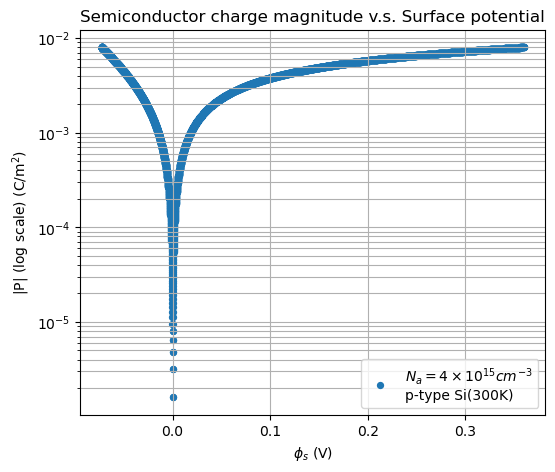

In [30]:
P_abs = np.abs(P_values)
mask = P_abs > 0  # 避免 log10(0)

plt.figure(figsize=(6, 5))
plt.scatter(phi_s_t[mask], P_abs[mask], s=18, label=r"$N_a=4\times10^{15}cm^{-3}$"+"\n"+r"p-type Si(300K)")
plt.yscale("log")
plt.title("Semiconductor charge magnitude v.s. Surface potential")
plt.xlabel(r"$\phi_s$ (V)")
plt.ylabel("|P| (log scale) (C/m$^2$)")
plt.grid(True, which="both")
plt.legend()

In [31]:
# ============================================================
# 6. Landau model
# ============================================================
def VFE_landau(P, alpha, beta_L, gamma,Pimp=0, Vimp=0):
    return tFE * (alpha * (P+Pimp) + beta_L * (P+Pimp)**3 + gamma * (P+Pimp)**5) + Vimp


def residual_landau(params, P, VFE_target, weights=None):
    alpha, beta_L, gamma = params

    VFE_fit = VFE_landau(P, alpha, beta_L, gamma)

    r = VFE_fit - VFE_target

    if weights is not None:
        r = r * weights

    return r



In [32]:
P_plot = P_exp /0.01  # C/m^2 -> uC/cm^2
P_plottf = P_exptf /0.01  # C/m^2 -> uC/cm^2
N = len(Vg_exp)



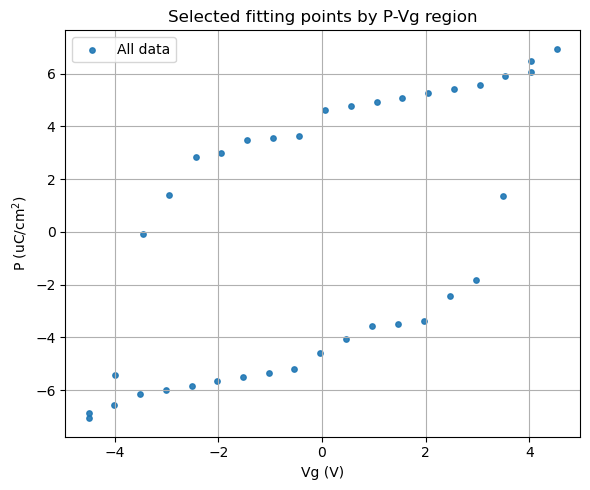

In [33]:
plt.figure(figsize=(6, 5))

plt.scatter(Vg_exp, -P_plot, s=15, alpha=0.9, label="All data")
#plt.scatter(Vg_exptf, P_plottf, s=35, label="Selected")


plt.xlabel("Vg (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("Selected fitting points by P-Vg region")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## main

In [34]:

# ============================================================
# 4. Compute phi_s and experimental VFE
# ============================================================

phi_s_exptf = np.array([solve_phi_s_from_P(P) for P in P_exptf])
phi_s_exp = np.array([solve_phi_s_from_P(P) for P in P_exp]) 

# Qs ≈ -P
Qs_exptf = -P_exptf
Qs_exp = -P_exp

# VIL = -Qs * tIL / (eps_IL_rel * eps0)
# since Qs = -P, VIL = P * tIL / (eps_IL_rel * eps0)
VIL_exptf = -Qs_exptf * tIL / (eps_IL_rel * eps0)
VIL_exp = -Qs_exp * tIL / (eps_IL_rel * eps0)

VFE_exptf = Vg_exptf - Vfb - VIL_exptf - phi_s_exptf
VFE_exp = Vg_exp - Vfb - VIL_exp - phi_s_exp


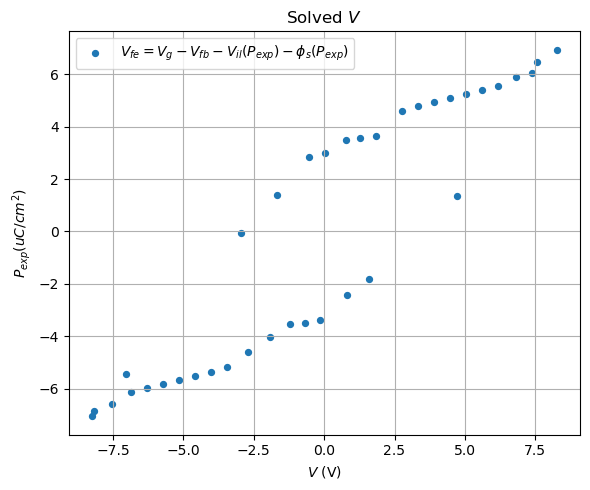

In [35]:
plt.figure(figsize=(6, 5))
Vfb_plot = Vfb * np.ones_like(P_exp)
Vg_add = Vfb_plot+VFE_exp+VIL_exp+phi_s_exp
#plt.scatter(P_exp / 0.01, Vg_exp, s=18, label=r"$V_g$")
plt.scatter(VFE_exp, -P_exp / 0.01, s=18, label=r"$V_{fe}=V_g-V_{fb}-V_{il}(P_{exp})-\phi_s(P_{exp})$")
#plt.scatter(P_exp / 0.01, VIL_exp, s=18, label=r"$V_{il}(P_{exp})$")
#plt.scatter(P_exp / 0.01, phi_s_exp, s=18, label=r"$\phi_s(P_{exp})$")
#plt.scatter(P_exp / 0.01, Vfb_plot, s=18, label=r"$V_{fb}$")
#plt.scatter(P_exp / 0.01, Vg_add, s=18, label=r"$V_g=V_{fb}+V_{fe}+V_{il}+\phi_s$")

plt.xlabel(r"$V$ (V)")
plt.ylabel(r"$P_{exp} (uC/cm^2)$")
plt.title(r"Solved $V$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

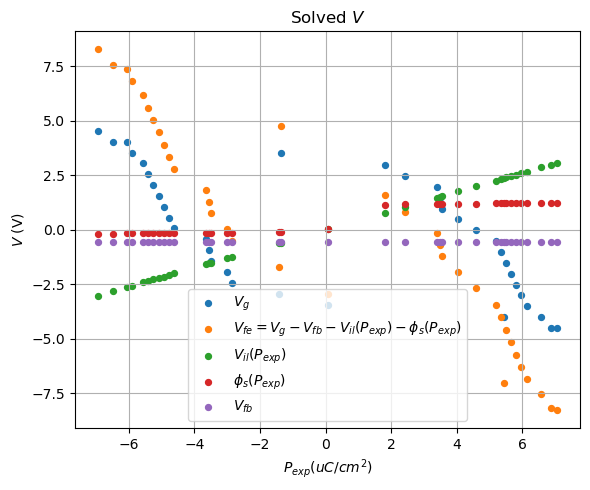

In [36]:
plt.figure(figsize=(6, 5))
Vfb_plot = Vfb * np.ones_like(P_exp)
Vg_add = Vfb_plot+VFE_exp+VIL_exp+phi_s_exp
plt.scatter(P_exp / 0.01, Vg_exp, s=18, label=r"$V_g$")
plt.scatter(P_exp / 0.01, VFE_exp, s=18, label=r"$V_{fe}=V_g-V_{fb}-V_{il}(P_{exp})-\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, VIL_exp, s=18, label=r"$V_{il}(P_{exp})$")
plt.scatter(P_exp / 0.01, phi_s_exp, s=18, label=r"$\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, Vfb_plot, s=18, label=r"$V_{fb}$")
#plt.scatter(P_exp / 0.01, Vg_add, s=18, label=r"$V_g=V_{fb}+V_{fe}+V_{il}+\phi_s$")

plt.xlabel(r"$P_{exp} (uC/cm^2)$")
plt.ylabel(r"$V$ (V)")
plt.title(r"Solved $V$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [37]:
# ============================================================
# 7. Fitting alpha, beta, gamma
# ============================================================

# 初始值很重要。這組只是 generic guess，通常你要依材料調整。
# alpha 單位約 m/F
# beta  單位 m^5/(C^2 F)
# gamma 單位 m^9/(C^4 F)
x0 = np.array([
    -4.330846e+06,   # alpha
     8.890780e+06,  # beta_L
     03.871486e+06  # gamma
           # Vimp
], dtype=float)

# 如果想限制物理符號，可以打開 bounds
# 典型 sixth-order FE:
# alpha < 0, beta 可以正或負，gamma > 0
bounds_lower = np.array([-np.inf, -np.inf, 0.0])
bounds_upper = np.array([0.0, np.inf, np.inf])

# branch 權重，先全部設成 1
weights = np.ones_like(P_exptf)

# 你也可以讓 up/down branch 權重相同，避免某一段點數比較多
# 例如：
# weights[up_mask] = 1.0 / np.sqrt(np.sum(up_mask))
# weights[down_mask] = 1.0 / np.sqrt(np.sum(down_mask))

result = least_squares(
    residual_landau,
    x0=x0,
    bounds=(bounds_lower, bounds_upper),
    args=(P_exptf, -VFE_exptf, weights),
    loss="soft_l1",
    f_scale=0.2,
    max_nfev=50000,
    verbose=1
)

alpha_fit, beta_fit, gamma_fit = result.x
print("\n===== Fit result =====")
print(f"alpha = {alpha_fit:.6e}")
print(f"beta  = {beta_fit:.6e}")
print(f"gamma = {gamma_fit:.6e}")
#print(f"Pimp  = {Pimp_fit:.6e} C/m^2")
#print(f"Vimp  = {Vimp_fit:.6e} V")

print("\n===== Optimization info =====")
print("success:", result.success)
print("message:", result.message)
print("cost:", result.cost)

VFE_fit = VFE_landau(P_exptf, alpha_fit, beta_fit, gamma_fit)

rmse_VFE = np.sqrt(np.mean((VFE_fit - VFE_exptf)**2))
print(f"\nVFE RMSE = {rmse_VFE:.6e} V")


# ============================================================
# 8. Convert fitted VFE back to Vg
# ============================================================

Vg_fit = Vfb + VFE_fit + VIL_exptf + phi_s_exptf

rmse_Vg = np.sqrt(np.mean((Vg_fit - Vg_exptf)**2))
print(f"Vg RMSE = {rmse_Vg:.6e} V")

`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 2.8885e+01, final cost 2.8876e+01, first-order optimality 6.63e-12.

===== Fit result =====
alpha = -5.286022e-04
beta  = 3.798199e+07
gamma = 3.971130e+06

===== Optimization info =====
success: True
message: `gtol` termination condition is satisfied.
cost: 28.876296597115154

VFE RMSE = 4.839111e+00 V
Vg RMSE = 4.839111e+00 V


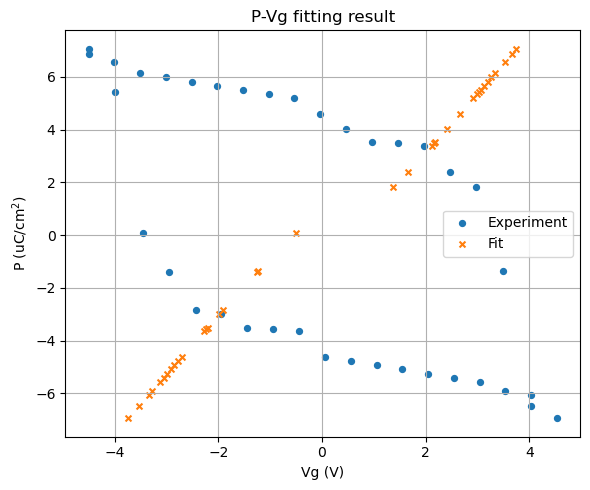

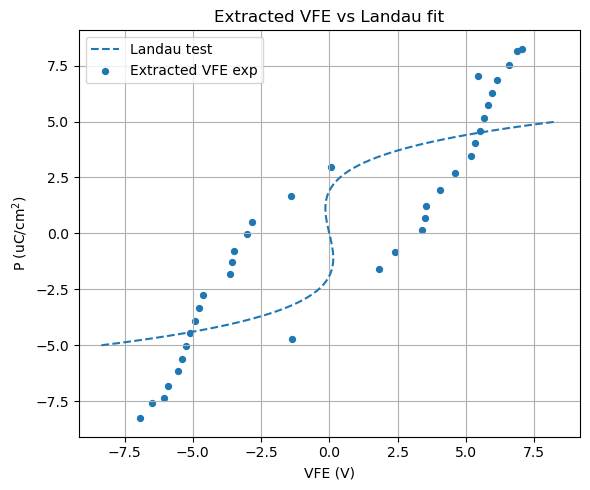

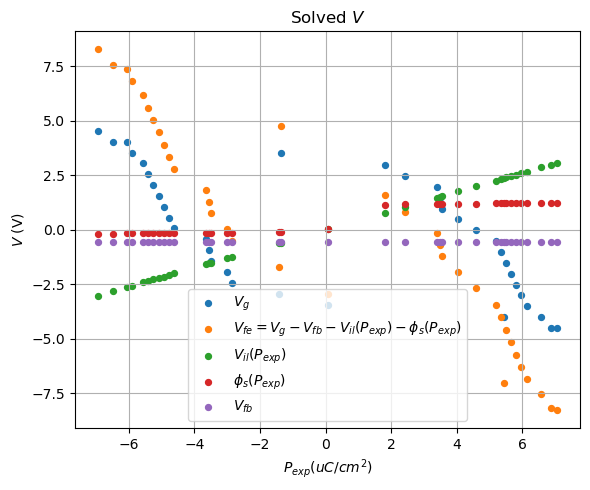

In [38]:

# ============================================================
# 9. Plot results
# ============================================================

plt.figure(figsize=(6, 5))
plt.scatter(Vg_exptf, P_exptf / 0.01, s=18, label="Experiment")
plt.scatter(Vg_fit, P_exptf / 0.01, s=18, label="Fit", marker="x")
plt.xlabel("Vg (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("P-Vg fitting result")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
x = np.linspace(-5, 5, 100)
y = VFE_landau(x, alpha_fit, beta_fit, gamma_fit)
y_t = VFE_landau(x, -2.748887e+07, 7.097707e+06, 1.416806e5)
#plt.plot(y, x, label="Landau fit curve")
plt.plot(y_t, x, label="Landau test", linestyle="dashed")
plt.scatter(P_exp / 0.01, -VFE_exp, s=18, label="Extracted VFE exp")
#plt.scatter(VFE_fit, P_exptf / 0.01, s=18, label="Landau fit", marker="x")
plt.xlabel("VFE (V)")
plt.ylabel("P (uC/cm$^2$)")
plt.title("Extracted VFE vs Landau fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




plt.figure(figsize=(6, 5))
Vfb_plot = Vfb * np.ones_like(P_exp)
Vg_add = Vfb_plot+VFE_exp+VIL_exp+phi_s_exp
plt.scatter(P_exp / 0.01, Vg_exp, s=18, label=r"$V_g$")
plt.scatter(P_exp / 0.01, VFE_exp, s=18, label=r"$V_{fe}=V_g-V_{fb}-V_{il}(P_{exp})-\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, VIL_exp, s=18, label=r"$V_{il}(P_{exp})$")
plt.scatter(P_exp / 0.01, phi_s_exp, s=18, label=r"$\phi_s(P_{exp})$")
plt.scatter(P_exp / 0.01, Vfb_plot, s=18, label=r"$V_{fb}$")
#plt.scatter(P_exp / 0.01, Vg_add, s=18, label=r"$V_g=V_{fb}+V_{fe}+V_{il}+\phi_s$")

plt.xlabel(r"$P_{exp} (uC/cm^2)$")
plt.ylabel(r"$V$ (V)")
plt.title(r"Solved $V$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [39]:
print("P uC/cm2:", P_plot.min(), P_plot.max())
print("phi_s:", phi_s_exp.min(), phi_s_exp.max())
print("VIL:", VIL_exp.min(), VIL_exp.max())
print("VFE_exp:", VFE_exp.min(), VFE_exp.max())

P uC/cm2: -6.94188248737374 7.061053177500689
phi_s: -0.17811435608511073 1.2247559853220344
VIL: -3.0154711637991807 3.0672374937970566
VFE_exp: -8.24934363011092 8.26258862623381
